Material for the book [Probability and Statistics for Data Science](https://a.co/d/cAss9mO). A free preprint, videos, code, slides and solutions to exercises are available at https://www.ps4ds.net/ 

Prediction of electoral votes in Nebraska for the 2024 presidential election using data from the previous election and from a poll.\
Topics and relevant videos: [Bayesian parametric modeling, beta distribution, prior and posterior distributions](https://www.youtube.com/watch?v=G63ZmHg83mg)

Author: Carlos Fernandez-Granda

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import beta

# 2020 Election Data: (Trump, Biden)
priors_data = {
    "1st": (180290, 132261),
    "2nd": (154377, 176468),
    "3rd": (222179, 65854),
}

In [23]:
effective_n_prior = 50
priors = {}
for district, (trump, biden) in priors_data.items():
    ratio_trump = trump / (trump + biden)
    trump_corrected = ratio_trump * effective_n_prior
    biden_corrected = (1-ratio_trump) * effective_n_prior
    priors[district] = (trump_corrected, biden_corrected)
    a, b = priors[district]
    mean_p = a / (a + b);

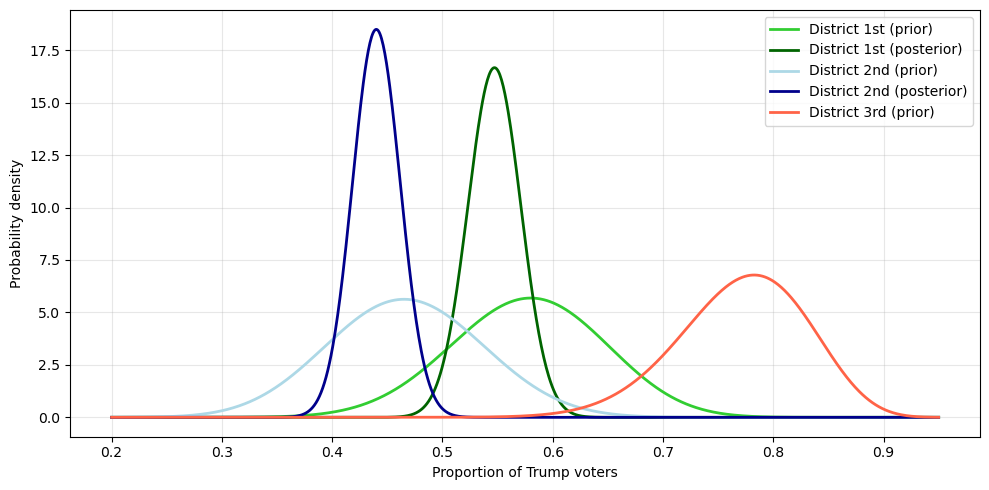

In [24]:
# 2024 Poll Data: (Trump, Harris)
poll_data = {"1st": (208, 175), "2nd": (210, 270)}

posteriors = {}

# Update 1st and 2nd districts
for district in ["1st", "2nd"]:
    a_prior, b_prior = priors[district]
    trump_poll, harris_poll = poll_data[district]

    # Posterior parameters
    a_post = a_prior + trump_poll
    b_post = b_prior + harris_poll
    posteriors[district] = (a_post, b_post)

# 3rd district: No poll data, posterior equals prior
posteriors["3rd"] = priors["3rd"]

# Plotting Prior PDFs
fig, ax = plt.subplots(figsize=(10, 5))
x = np.linspace(0.2, 0.95, 1000)

color_priors = ["limegreen","lightblue","tomato"]
color_posteriors = ["darkgreen","darkblue"]
district_counter = 0
for district, (a, b) in priors.items():
    district_counter += 1
    a_pr, b_pr = priors[district]
    a_po, b_po = posteriors[district]

    # Evaluate PDF using scipy.stats.beta
    ax.plot(x, beta.pdf(x, a, b),color = color_priors[district_counter-1],lw=2, label=f"District {district} (prior)")
    if district_counter < 3:
        ax.plot(x, beta.pdf(x, a_po, b_po),color = color_posteriors[district_counter-1],lw=2, label=f"District {district} (posterior)")
    
ax.set_xlabel("Proportion of Trump voters")
ax.set_ylabel("Probability density")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
# Turnout per district from 2020 totals
total_votes_2020 = {
    "1st": priors_data["1st"][0] + priors_data["1st"][1],
    "2nd": priors_data["2nd"][0] + priors_data["2nd"][1],
    "3rd": priors_data["3rd"][0] + priors_data["3rd"][1],
}

total_state_votes = sum(total_votes_2020.values())

n_sims = 500000
np.random.seed(42)

# Dictionary to store the counts for each possible electoral vote total (0 through 5)
ev_counts = {0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0}

for _ in range(n_sims):
    # Step 1: Draw a success probability (p) for each district from its beta posterior
    p1 = np.random.beta(posteriors["1st"][0], posteriors["1st"][1])
    p2 = np.random.beta(posteriors["2nd"][0], posteriors["2nd"][1])
    p3 = np.random.beta(posteriors["3rd"][0], posteriors["3rd"][1])

    # Step 2: Sample actual Trump votes for each district using binomial trials
    # (np.random.binomial works cleanly for single trials here)
    v1 = np.random.binomial(total_votes_2020["1st"], p1)
    v2 = np.random.binomial(total_votes_2020["2nd"], p2)
    v3 = np.random.binomial(total_votes_2020["3rd"], p3)

    # Step 3: Determine district electors (1 vote each)
    ev_trump = 0
    if v1 > total_votes_2020["1st"] / 2:
        ev_trump += 1
    if v2 > total_votes_2020["2nd"] / 2:
        ev_trump += 1
    if v3 > total_votes_2020["3rd"] / 2:
        ev_trump += 1

    # Step 4: Determine statewide electors (2 votes)
    total_trump_votes = v1 + v2 + v3
    if total_trump_votes > total_state_votes / 2:
        ev_trump += 2

    # Step 5: Record the result for this simulation
    ev_counts[ev_trump] += 1

for ev in range(6):
    prob = ev_counts[ev] / n_sims
    print(f"P(Trump Electoral Votes = {ev}): {prob:.4f}")

P(Trump Electoral Votes = 0): 0.0000
P(Trump Electoral Votes = 1): 0.0001
P(Trump Electoral Votes = 2): 0.0003
P(Trump Electoral Votes = 3): 0.0249
P(Trump Electoral Votes = 4): 0.9718
P(Trump Electoral Votes = 5): 0.0029
